Name: Rishi Phadale  
Roll No.: 23102C0070  
Subject: R Programming  
Experiment No.: 01  

# Task 1: Import and Inspect the Dataset

In [2]:
import_data <- function(file_path) {
  tryCatch({
    data <- read.csv(file_path, stringsAsFactors = FALSE)
    cat("File imported successfully!\n")
    return(data)
  },
  error = function(e) {
    if (grepl("cannot open", conditionMessage(e))) {
      cat("Error: File not found. Please check the file path.\n")
    } else {
      cat("Error: Unable to open the file. Details:", conditionMessage(e), "\n")
    }
    return(NULL)
  },
  warning = function(w) {
    cat("Warning while reading file:", conditionMessage(w), "\n")
  })
}

file_path <- "/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv"

air_data <- import_data(file_path)

File imported successfully!


In [3]:
if (!is.null(air_data)) {

  # 1. Display first six records
  cat("\n----- First Six Records -----\n")
  print(head(air_data))

  # 2. Display structure of the dataset
  cat("\n----- Structure of Dataset -----\n")
  str(air_data)

  # 3. Display number of rows and columns
  cat("\n----- Dimensions -----\n")
  cat("Number of rows:", nrow(air_data), "\n")
  cat("Number of columns:", ncol(air_data), "\n")

  # 4. Check whether dataset contains missing values
  cat("\n----- Missing Values Check -----\n")
  has_missing <- anyNA(air_data)
  cat("Does the dataset contain missing values?", has_missing, "\n")

  # 5. Display total number of missing values
  total_missing <- sum(is.na(air_data))
  cat("Total number of missing values:", total_missing, "\n")

} else {
  cat("Data import failed. Please check the file and try again.\n")
}


----- First Six Records -----
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

----- Structure of Dataset -----
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   :

# Task 2: Understand NA, NULL, and NaN

In [4]:
# NA example
temperature <- c(28, 30, NA, 32)
cat("----- NA Example -----\n")
print(temperature)
cat("Is NA present?\n")
print(is.na(temperature))

# NULL example
missing_object <- NULL
cat("\n----- NULL Example -----\n")
print(missing_object)
cat("Is it NULL?", is.null(missing_object), "\n")

# NaN example
undefined_value <- 0 / 0
cat("\n----- NaN Example -----\n")
print(undefined_value)
cat("Is it NaN?", is.nan(undefined_value), "\n")
cat("Is it also NA?", is.na(undefined_value), "\n")

# Summary comparison
cat("\n----- Summary -----\n")
cat("is.na(NA):", is.na(NA), "\n")
cat("is.null(NULL):", is.null(NULL), "\n")
cat("is.nan(0/0):", is.nan(0/0), "\n")

----- NA Example -----
[1] 28 30 NA 32
Is NA present?
[1] FALSE FALSE  TRUE FALSE

----- NULL Example -----
NULL
Is it NULL? TRUE 

----- NaN Example -----
[1] NaN
Is it NaN? TRUE 
Is it also NA? TRUE 

----- Summary -----
is.na(NA): TRUE 
is.null(NULL): TRUE 
is.nan(0/0): TRUE 


# Task 3: Create a Missing-Value Summary Function

In [5]:
missing_summary <- function(df) {
  variables <- names(df)
  total_records <- nrow(df)

  result <- data.frame(
    Variable = character(),
    Total_Records = numeric(),
    Missing_Values = numeric(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  for (var in variables) {
    missing_count <- sum(is.na(df[[var]]))
    missing_pct <- round((missing_count / total_records) * 100, 2)

    if (missing_pct > 20) {
      warning(paste("Variable", var, "has more than 20% missing values:", missing_pct, "%"))
    }

    result <- rbind(result, data.frame(
      Variable = var,
      Total_Records = total_records,
      Missing_Values = missing_count,
      Missing_Percentage = missing_pct
    ))
  }
  return(result)
}

selected_vars <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")
summary_table <- missing_summary(air_data[selected_vars])
print(summary_table)

  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


# Task 4: Identify Invalid Numerical Results

In [6]:
air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

cat("----- Checking pollution_ratio -----\n")
cat("Number of NA values:", sum(is.na(air_data$pollution_ratio)), "\n")
cat("Number of NaN values:", sum(is.nan(air_data$pollution_ratio)), "\n")
cat("Number of Positive Infinity values:", sum(air_data$pollution_ratio == Inf, na.rm = TRUE), "\n")
cat("Number of Negative Infinity values:", sum(air_data$pollution_ratio == -Inf, na.rm = TRUE), "\n")

# Replace NaN and Infinite values with NA
air_data$pollution_ratio[is.nan(air_data$pollution_ratio)] <- NA
air_data$pollution_ratio[is.infinite(air_data$pollution_ratio)] <- NA

cat("\n----- After Replacement -----\n")
cat("Number of NA values now:", sum(is.na(air_data$pollution_ratio)), "\n")
cat("Any NaN left?", any(is.nan(air_data$pollution_ratio)), "\n")
cat("Any Infinite left?", any(is.infinite(air_data$pollution_ratio)), "\n")

----- Checking pollution_ratio -----
Number of NA values: 934 
Number of NaN values: 0 
Number of Positive Infinity values: 0 
Number of Negative Infinity values: 0 

----- After Replacement -----
Number of NA values now: 934 
Any NaN left? FALSE 
Any Infinite left? FALSE 


# Task 5: Handle Missing Numerical Values Using a Loop

In [7]:
numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

# Store before-treatment missing counts for later comparison (Task 8)
missing_before <- numeric(length(numeric_variables))
names(missing_before) <- numeric_variables

for (i in seq_along(numeric_variables)) {
  var <- numeric_variables[i]

  if (!(var %in% names(air_data))) {
    cat("Column", var, "does not exist. Skipping.\n")
    next
  }

  missing_count_before <- sum(is.na(air_data[[var]]))
  missing_before[var] <- missing_count_before

  median_value <- median(air_data[[var]], na.rm = TRUE)

  air_data[[var]][is.na(air_data[[var]])] <- median_value

  missing_count_after <- sum(is.na(air_data[[var]]))

  cat("\nVariable:", var, "\n")
  cat("Missing values before treatment:", missing_count_before, "\n")
  cat("Median used for replacement:", median_value, "\n")
  cat("Missing values after treatment:", missing_count_after, "\n")
}


Variable: PM2.5 
Missing values before treatment: 925 
Median used for replacement: 58 
Missing values after treatment: 0 

Variable: PM10 
Missing values before treatment: 718 
Median used for replacement: 87 
Missing values after treatment: 0 

Variable: SO2 
Missing values before treatment: 935 
Median used for replacement: 9 
Missing values after treatment: 0 

Variable: NO2 
Missing values before treatment: 1023 
Median used for replacement: 53 
Missing values after treatment: 0 

Variable: TEMP 
Missing values before treatment: 20 
Median used for replacement: 14.5 
Missing values after treatment: 0 

Variable: WSPM 
Missing values before treatment: 14 
Median used for replacement: 1.4 
Missing values after treatment: 0 


# Task 6: Handle Missing Categorical Values

In [8]:
calculate_mode <- function(x) {
  x <- x[!is.na(x)]
  freq_table <- table(x)
  mode_value <- names(freq_table)[which.max(freq_table)]
  return(mode_value)
}

missing_wd_before <- sum(is.na(air_data$wd))
cat("Missing values in 'wd' before replacement:", missing_wd_before, "\n")

wd_mode <- calculate_mode(air_data$wd)
cat("Mode of 'wd':", wd_mode, "\n")

air_data$wd[is.na(air_data$wd)] <- wd_mode

missing_wd_after <- sum(is.na(air_data$wd))
cat("Missing values in 'wd' after replacement:", missing_wd_after, "\n")

Missing values in 'wd' before replacement: 81 
Mode of 'wd': NE 
Missing values in 'wd' after replacement: 0 


# Task 7: Implement Error Handling

In [9]:
clean_variable <- function(df, var_name) {
  tryCatch({

    if (!(var_name %in% names(df))) {
      stop(paste("Variable", var_name, "does not exist in the dataset."))
    }

    variable <- df[[var_name]]

    if (!is.numeric(variable)) {
      stop(paste(var_name, "is categorical, not numerical."))
    }

    if (all(is.na(variable))) {
      stop(paste(var_name, "contains only missing values."))
    }

    median_value <- median(variable, na.rm = TRUE)

    if (is.na(median_value)) {
      stop(paste("Median could not be calculated for", var_name))
    }

    variable[is.na(variable)] <- median_value
    cat("Variable", var_name, "cleaned successfully.\n")
    return(variable)

  },
  error = function(e) {
    cat("Error while cleaning", var_name, ":", conditionMessage(e), "\n")
    return(NULL)
  })
}

# Example usage
air_data$SO2 <- clean_variable(air_data, "SO2")
test_result <- clean_variable(air_data, "wd")        # categorical - should show error
test_result2 <- clean_variable(air_data, "NotAColumn") # nonexistent - should show error

Variable SO2 cleaned successfully.
Error while cleaning wd : wd is categorical, not numerical. 
Error while cleaning NotAColumn : Variable NotAColumn does not exist in the dataset. 


# Task 8: Compare Missing Values Before and After Cleaning

In [10]:
all_vars <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

missing_after <- sapply(air_data[all_vars], function(x) sum(is.na(x)))

comparison_table <- data.frame(
  Variable = all_vars,
  Missing_Before = c(missing_before, missing_wd_before),
  Missing_After = as.numeric(missing_after),
  stringsAsFactors = FALSE
)

comparison_table$Values_Replaced <- comparison_table$Missing_Before - comparison_table$Missing_After

print(comparison_table)

cat("\nInterpretation: All selected variables show zero missing values after cleaning,\n")
cat("confirming that the imputation (median for numeric, mode for categorical) was successful.\n")

      Variable Missing_Before Missing_After Values_Replaced
PM2.5    PM2.5            925             0             925
PM10      PM10            718             0             718
SO2        SO2            935             0             935
NO2        NO2           1023             0            1023
TEMP      TEMP             20             0              20
WSPM      WSPM             14             0              14
            wd             81             0              81

Interpretation: All selected variables show zero missing values after cleaning,
confirming that the imputation (median for numeric, mode for categorical) was successful.


# Task 9: Generate One Visualization

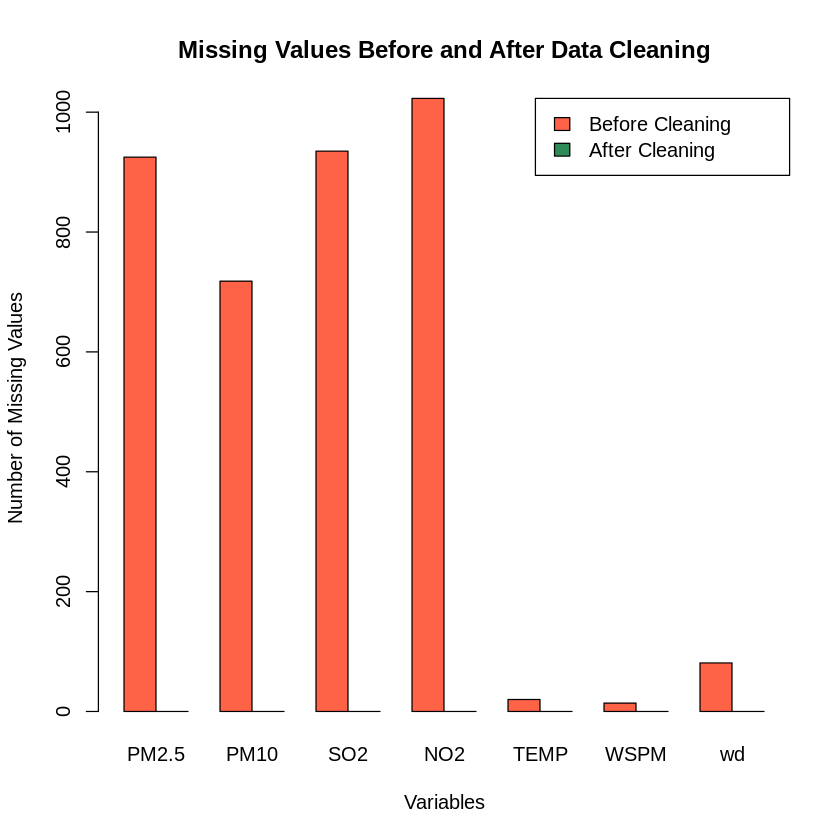

In [11]:
# Prepare data for plotting
plot_data <- matrix(
  c(comparison_table$Missing_Before, comparison_table$Missing_After),
  nrow = 2, byrow = TRUE
)
colnames(plot_data) <- comparison_table$Variable
rownames(plot_data) <- c("Before Cleaning", "After Cleaning")

barplot(plot_data,
        beside = TRUE,
        col = c("tomato", "seagreen"),
        main = "Missing Values Before and After Data Cleaning",
        xlab = "Variables",
        ylab = "Number of Missing Values",
        legend.text = TRUE,
        args.legend = list(x = "topright"))

# Task 10: Export the Cleaned Dataset

In [12]:
write.csv(air_data, "cleaned_air_quality_data.csv", row.names = FALSE)
cat("Cleaned dataset exported successfully as 'cleaned_air_quality_data.csv'\n")

# For Google Colab - download the file
system("cp cleaned_air_quality_data.csv /content/")

Cleaned dataset exported successfully as 'cleaned_air_quality_data.csv'


The notebook successfully imported and inspected an air quality dataset. It demonstrated the differences between `NA`, `NULL`, and `NaN` values. A custom function was created to summarize missing values, revealing low percentages (under 3%) for critical variables. Invalid numerical results like `NaN` and `Inf` were identified and replaced with `NA`. Missing numerical values were then imputed using their respective medians, and missing categorical values were handled by replacing them with the mode. Error handling was also implemented to robustly clean variables. A comparison table and a bar plot visually confirmed that all targeted missing values were effectively addressed. Finally, the cleaned dataset was exported.